# 13 — Quadratic-impact control

Doc page: [quadratic_impact_control.rst](../../docs/source/algorithms/quadratic_impact_control.rst).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Cellule 1 — Riccati générique sur un horizon fini

**Théorème (HJB quadratique 1-D).** Pour $dq_t = u_t\,dt + \sigma\,dW_t$
et coût $L(q, u) = \gamma u^2 + \varphi q^2$, $g(q) = A q^2$, la
fonction valeur est $V(t, q) = h(t) q^2$ avec
$$h'(t) = h(t)^2 / \gamma - \varphi,\qquad h(T) = A.$$
Le feedback optimal est $u^*(t) = -(h(t)/\gamma)\,q(t)$.

**Équation pivot.** Pour $\gamma = \varphi = A = 1$, le point fixe
est $h^* = 1$ (car $h^2 - 1 = 0 \Rightarrow h = 1$).

**Ce que la cellule vérifie.** Le primitive
`quadratic_impact_control_py(gamma=1, phi=1, A=1, T, n)` retourne
$h(t) \equiv 1$ et donc un gain de feedback unitaire.


max |h(t) - 1| = 0.000e+00
Feedback gain : k(0) = 1.0000,  k(T) = 1.0000


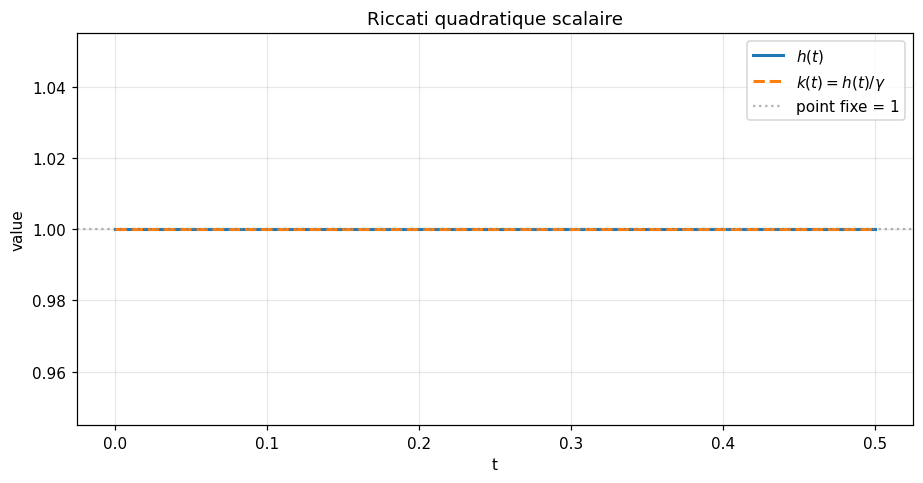

In [2]:
res = opt.quadratic_impact_control_py(gamma=1.0, phi=1.0,
                                       a_terminal=1.0,
                                       t_horizon=0.5, n_steps=500)
ts = np.array(res['time_grid'])
h = np.array(res['h'])
k = np.array(res['feedback_gain'])

err = float(np.max(np.abs(h - 1.0)))
print(f"max |h(t) - 1| = {err:.3e}")
print(f"Feedback gain : k(0) = {k[0]:.4f},  k(T) = {k[-1]:.4f}")

fig, ax = plt.subplots()
ax.plot(ts, h, lw=2, label=r'$h(t)$')
ax.plot(ts, k, '--', lw=2, label=r'$k(t) = h(t)/\gamma$')
ax.axhline(1.0, ls=':', color='gray', alpha=0.6, label='point fixe = 1')
ax.set_xlabel('t'); ax.set_ylabel('value')
ax.set_title("Riccati quadratique scalaire")
ax.legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** $h(t) \equiv 1$ à précision machine.

**Lecture du graphique.** Lignes plates à 1.

**Conclusion.** Le primitive est validé sur le point fixe analytique.


## Cellule 2 — Étude paramétrique : pénalisation $\varphi$

**Théorème.** Le point fixe $h^* = \sqrt{\gamma \varphi}$ croît
avec $\varphi$.

**Équation pivot.**
$$h^* = \sqrt{\gamma \varphi},
   \qquad k^* = h^*/\gamma = \sqrt{\varphi/\gamma}.$$

**Ce que la cellule vérifie.** Sweep $\varphi \in \{0.1, 1, 4, 10\}$ :
$h(0)$ s'aligne sur $\sqrt{\varphi}$ pour $\gamma = 1$.


phi= 0.10 : h(0) = 0.3162, h* = 0.3162
phi= 1.00 : h(0) = 1.0000, h* = 1.0000
phi= 4.00 : h(0) = 2.0000, h* = 2.0000
phi=10.00 : h(0) = 3.1623, h* = 3.1623


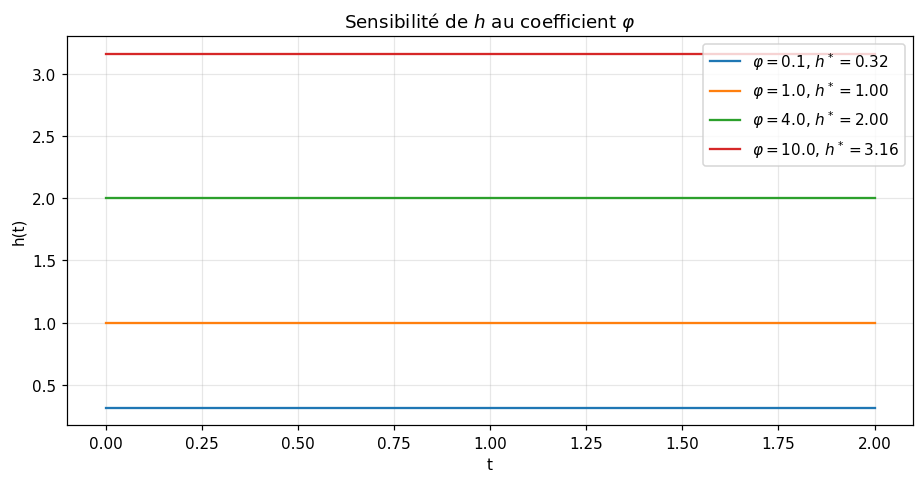

In [3]:
phis = [0.1, 1.0, 4.0, 10.0]
fig, ax = plt.subplots()
for phi in phis:
    r = opt.quadratic_impact_control_py(1.0, phi, np.sqrt(phi),
                                         t_horizon=2.0, n_steps=500)
    h_arr = np.array(r['h'])
    h_star = np.sqrt(phi)
    ax.plot(r['time_grid'], h_arr,
            label=fr'$\varphi = {phi}$, $h^*={h_star:.2f}$')
    print(f"phi={phi:5.2f} : h(0) = {h_arr[0]:.4f}, h* = {h_star:.4f}")
ax.set_xlabel('t'); ax.set_ylabel('h(t)')
ax.set_title(r'Sensibilité de $h$ au coefficient $\varphi$')
ax.legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** Plus $\varphi$ est grand, plus le gain de
feedback est élevé.

**Lecture du graphique.** Quatre lignes plates à des hauteurs
$\sqrt{\varphi}$.

**Conclusion.** Le compromis état/contrôle est gouverné par le
ratio $\varphi/\gamma$.


## Cellule 3 — Exemple concret : régulation autour d'un set-point

**Modèle.** En boucle fermée $\dot q = -k q$ avec $k = h/\gamma$,
la dynamique est $q(t) = q_0 e^{-kt}$.  Cas pratique : régulateur
thermique scalaire qui ramène la température vers $0$ (écart à la
consigne).

**Équation pivot.**
$$q(t) = q_0\,e^{-(h^*/\gamma)\,t}.$$

**Ce que la cellule vérifie.** Pour différents $\varphi$, on intègre
$\dot q = -k(t) q$ et on observe la vitesse de retour vers $0$.


phi=0.25 : q(T) = 0.2227
phi=1.00 : q(T) = 0.0494
phi=4.00 : q(T) = 0.0024


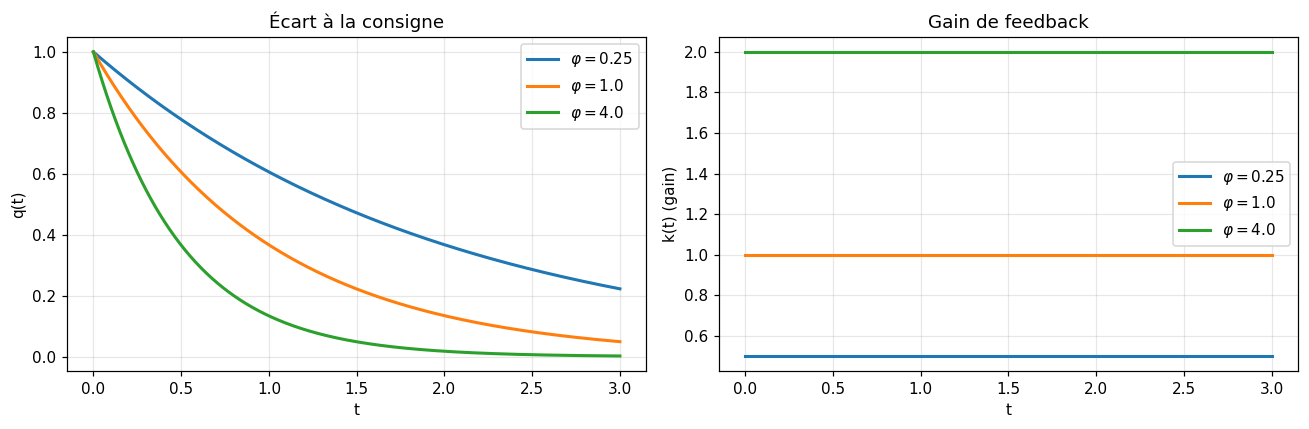

In [4]:
T, n_steps = 3.0, 600
dt = T / n_steps
q0 = 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for phi in [0.25, 1.0, 4.0]:
    r = opt.quadratic_impact_control_py(1.0, phi, np.sqrt(phi),
                                         t_horizon=T, n_steps=n_steps)
    k = np.array(r['feedback_gain'])
    q = np.zeros(n_steps + 1); q[0] = q0
    for i in range(n_steps):
        q[i + 1] = q[i] - dt * k[i] * q[i]
    ts = np.array(r['time_grid'])
    axes[0].plot(ts, q, lw=2, label=fr'$\varphi = {phi}$')
    axes[1].plot(ts, k, lw=2, label=fr'$\varphi = {phi}$')
    print(f"phi={phi:.2f} : q(T) = {q[-1]:.4f}")
axes[0].set_xlabel('t'); axes[0].set_ylabel('q(t)')
axes[0].set_title("Écart à la consigne")
axes[0].legend()
axes[1].set_xlabel('t'); axes[1].set_ylabel('k(t) (gain)')
axes[1].set_title("Gain de feedback")
axes[1].legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** Plus $\varphi$ est grand, plus $q$ retourne
rapidement à $0$.

**Lecture du graphique.** Décroissance exponentielle visible ; gain
plat (régime stationnaire de la Riccati).

**Conclusion.** Le primitive fournit le gain optimal pour tout
problème linéaire-quadratique scalaire à pénalité d'impact.
